# Intro to Aperiodic Flow Metrics

This notebook introduces **order-flow analytics** with the `aperiodic` Python package.
We focus on a single large-cap instrument — **Binance BTC perpetuals**
(`perpetual-BTC-USDT:USDT`) — over the exact six-month window from **September 1, 2025**
through **February 28, 2026**, using **1-hour** observations.

## Why flow matters

Order-flow metrics try to answer a simple question: **who was more aggressive — buyers or sellers?**
In futures markets, taker flow and cumulative delta are often used as short-horizon pressure gauges,
while trade concentration and toxicity-style metrics help highlight potentially more informed or more urgent activity.

Aperiodic exposes a rich `flow` metric family including taker buy/sell volume, counts, notional delta,
flow entropy, and toxicity-style features.

**Background reading**
- Aperiodic product overview: https://aperiodic.io/
- Binance Academy, makers vs takers: https://www.binance.com/en/academy/articles/what-are-makers-and-takers
- Binance Academy, order books: https://www.binance.com/en/academy/articles/what-is-an-order-book-and-how-does-it-work

In [1]:
from __future__ import annotations

import os
from datetime import date

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from aperiodic import get_metrics, get_ohlcv

sns.set_theme(style="whitegrid", context="talk", palette="deep")
pd.options.display.float_format = "{:,.4f}".format
plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 140
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

EXCHANGE = "binance-futures"
SYMBOL = "perpetual-BTC-USDT:USDT"
INTERVAL = "1h"
START_DATE = date(2025, 9, 1)
END_DATE = date(2026, 2, 28)
START_TS = pd.Timestamp(START_DATE)
END_TS = pd.Timestamp(END_DATE) + pd.Timedelta(days=1)

API_KEY = "..."  # Set via APERIODIC_API_KEY env var or .env file
if API_KEY == "...":
    API_KEY = os.getenv("APERIODIC_API_KEY", "...")
if API_KEY == "...":
    raise RuntimeError("Set APERIODIC_API_KEY in the environment or in .env.")


def clip_window(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out["time"] = pd.to_datetime(out["time"])
    out = out.loc[(out["time"] >= START_TS) & (out["time"] < END_TS)]
    return out.sort_values("time").reset_index(drop=True)

def format_time_axis(ax):
    locator = mdates.AutoDateLocator(minticks=6, maxticks=10)
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)



def pct_bps(series: pd.Series) -> pd.Series:
    return series * 10_000

## Fetch BTC OHLCV context and flow metrics

Aperiodic's SDK downloads partitioned aggregates efficiently. We clip the returned frames to the exact
analysis window so the notebook stays on a strict six-month horizon.

In [2]:
price = clip_window(
    get_ohlcv(
        api_key=API_KEY,
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=False,
    )
)

flow = clip_window(
    get_metrics(
        api_key=API_KEY,
        metric="flow",
        timestamp="true",
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=False,
    )
)

len(price), len(flow)

(4344, 4344)

In [3]:
flow = flow.merge(price[["time", "close", "volume_notional"]], on="time", how="left")
flow["net_delta"] = flow["volume_delta"]
flow["cumulative_delta"] = flow["net_delta"].cumsum()
flow["net_delta_notional_m"] = flow["volume_delta_notional"] / 1_000_000
flow["rolling_net_delta_1d"] = flow["net_delta_notional_m"].rolling(24).sum()
flow["rolling_buy_sell_ratio_1d"] = flow["taker_buy_sell_ratio"].rolling(24).mean()
flow["flow_toxicity_score"] = flow["flow_toxicity_score"].fillna(0)
flow["large_trade_share"] = (
    flow["taker_buy_large_order_count"] + flow["taker_sell_large_order_count"]
) / (flow["taker_buy_count"] + flow["taker_sell_count"])
flow["large_trade_share_1d"] = flow["large_trade_share"].rolling(24).mean()
flow["next_1h_return_bps"] = pct_bps(flow["close"].pct_change(1).shift(-1))
flow["abs_delta_zscore_1d"] = (
    flow["net_delta_notional_m"].abs() - flow["net_delta_notional_m"].rolling(24).mean()
) / flow["net_delta_notional_m"].rolling(24).std()

summary = pd.Series(
    {
        "Rows": len(flow),
        "Start": flow["time"].min(),
        "End": flow["time"].max(),
        "Mean buy/sell ratio": flow["taker_buy_sell_ratio"].mean(),
        "Median toxicity score": flow["flow_toxicity_score"].median(),
        "Average 1h net delta (BTC)": flow["net_delta"].mean(),
        "Average large-trade share": flow["large_trade_share"].mean(),
    }
)
summary

Rows                                         4344
Start                         2025-09-01 00:00:00
End                           2026-02-28 23:00:00
Mean buy/sell ratio                        1.0075
Median toxicity score                     -0.0089
Average 1h net delta (BTC)               -76.1986
Average large-trade share                  0.2700
dtype: object

## First look at the data

In [4]:
flow[[
    "time",
    "close",
    "taker_buy_volume",
    "taker_sell_volume",
    "net_delta",
    "net_delta_notional_m",
    "flow_toxicity_score",
    "large_trade_share",
]].head()

,time,close,taker_buy_volume,taker_sell_volume,net_delta,net_delta_notional_m,flow_toxicity_score,large_trade_share
0,2025-09-01 00:00:00,"108,180.1000","4,892.2700","5,100.5171",-208.2470,-22.5368,0.0000,0.3084
1,2025-09-01 01:00:00,"108,110.0000","2,101.6680","2,072.3799",29.2880,3.2076,-0.5000,0.2365
2,2025-09-01 02:00:00,"107,590.4000","3,320.0071","3,328.5540",-8.5470,-0.9925,-0.1714,0.2771
3,2025-09-01 03:00:00,"107,619.1000","2,333.7930","1,919.6010",414.1920,44.5875,-0.9302,0.2982
4,2025-09-01 04:00:00,"107,369.2000","2,071.9260","2,540.1599",-468.2340,-50.1726,0.6435,0.3136


## Charts 1-2 — BTC price and aggressive buy/sell flow

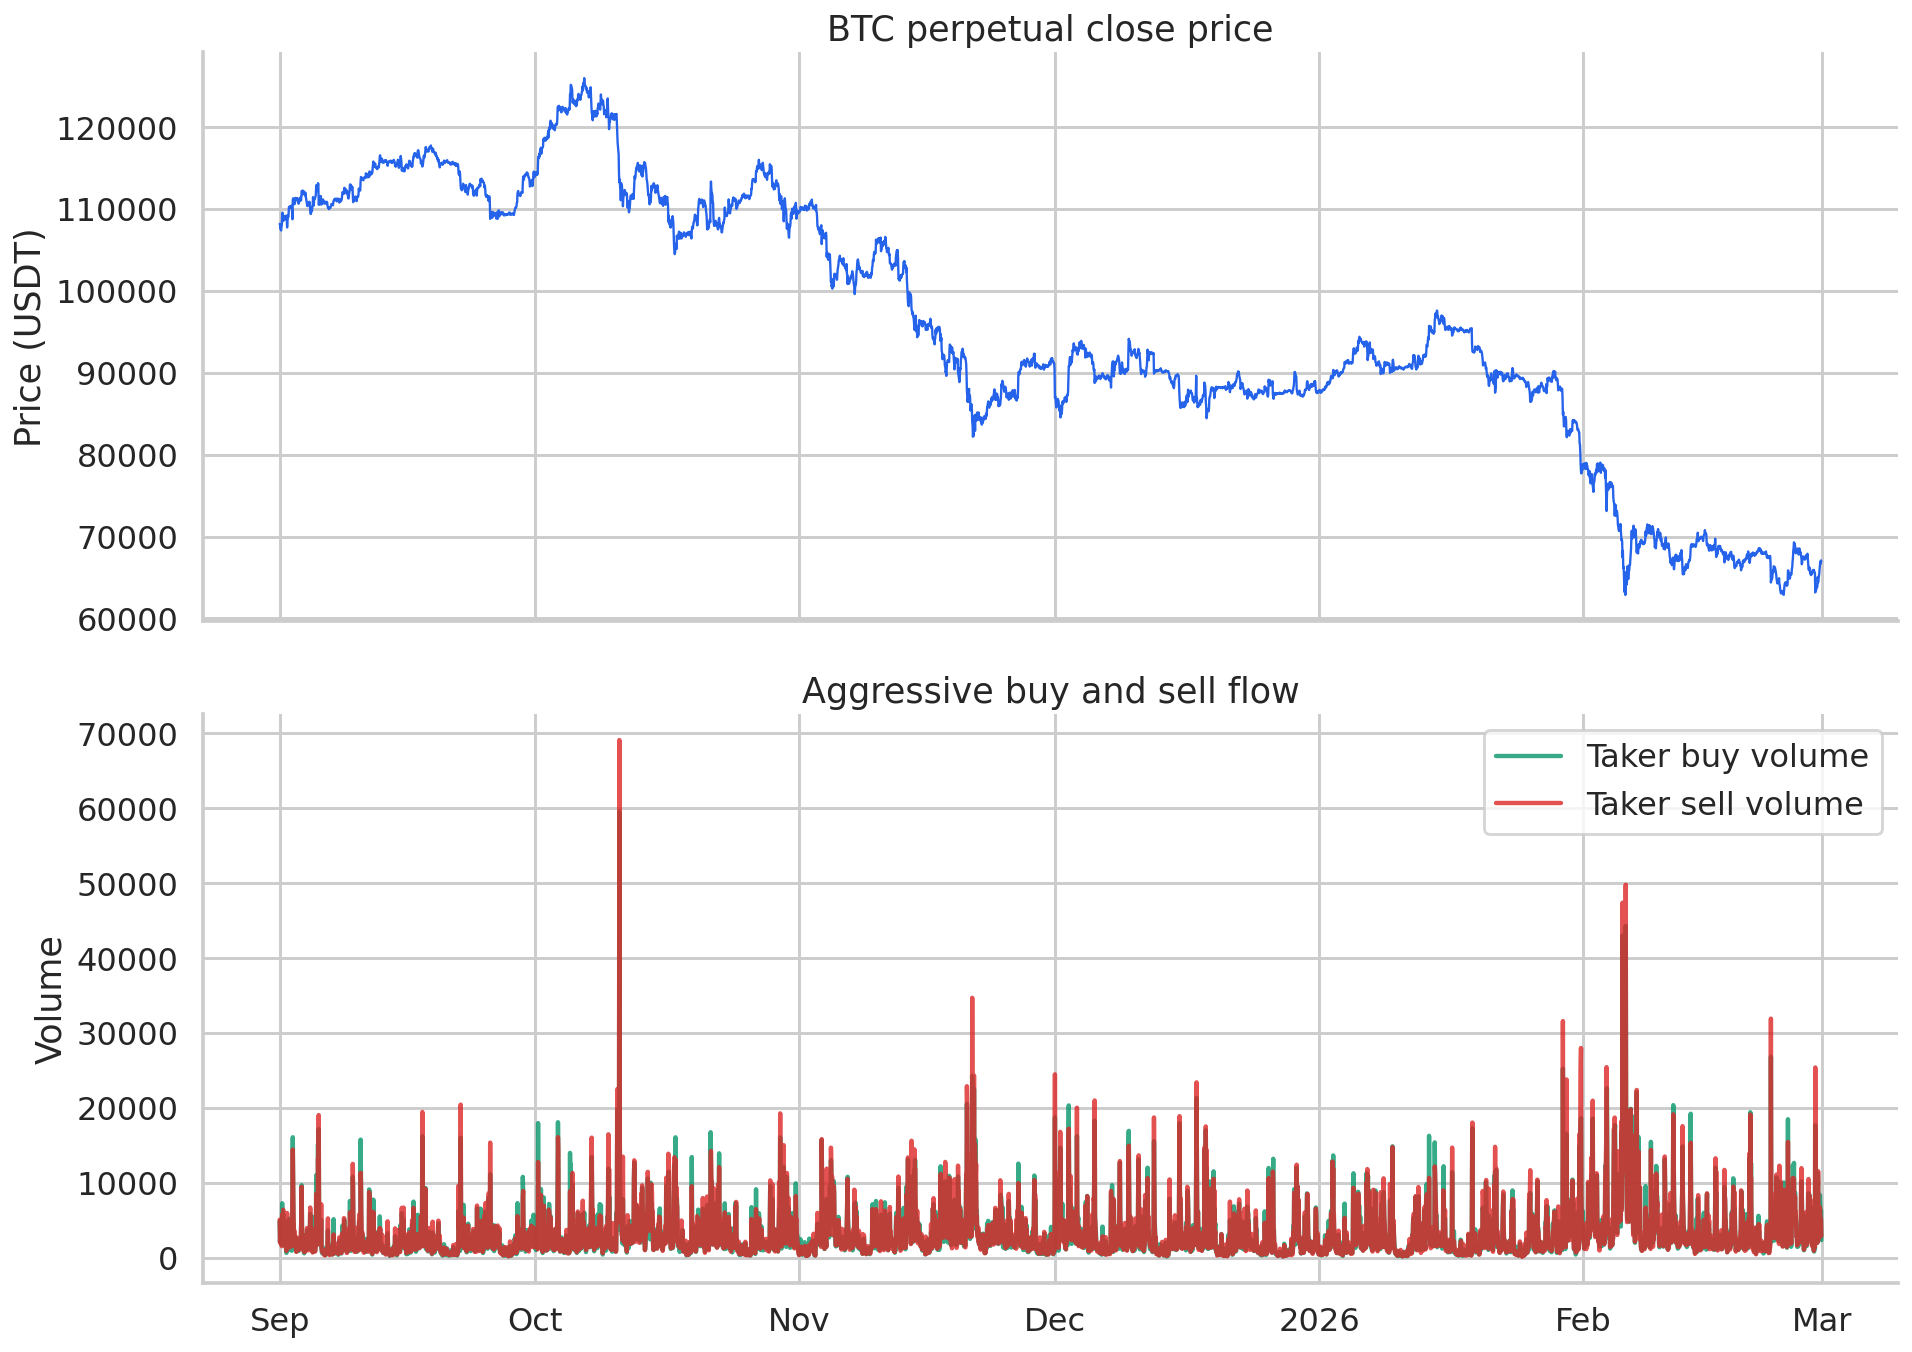

In [5]:
fig, (ax_price, ax_flow) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax_price.plot(price["time"], price["close"], color="#2563eb", linewidth=1.2)
ax_price.set_title("BTC perpetual close price")
ax_price.set_ylabel("Price (USDT)")
format_time_axis(ax_price)

ax_flow.plot(flow["time"], flow["taker_buy_volume"], label="Taker buy volume", color="#059669", alpha=0.8)
ax_flow.plot(flow["time"], flow["taker_sell_volume"], label="Taker sell volume", color="#dc2626", alpha=0.8)
ax_flow.set_title("Aggressive buy and sell flow")
ax_flow.set_ylabel("Volume")
ax_flow.legend(frameon=True)
format_time_axis(ax_flow)
plt.tight_layout()

## Chart 3 — Cumulative delta and BTC price

Cumulative delta summarizes whether aggressive buying or selling dominated over the full sample, alongside BTC price for context.

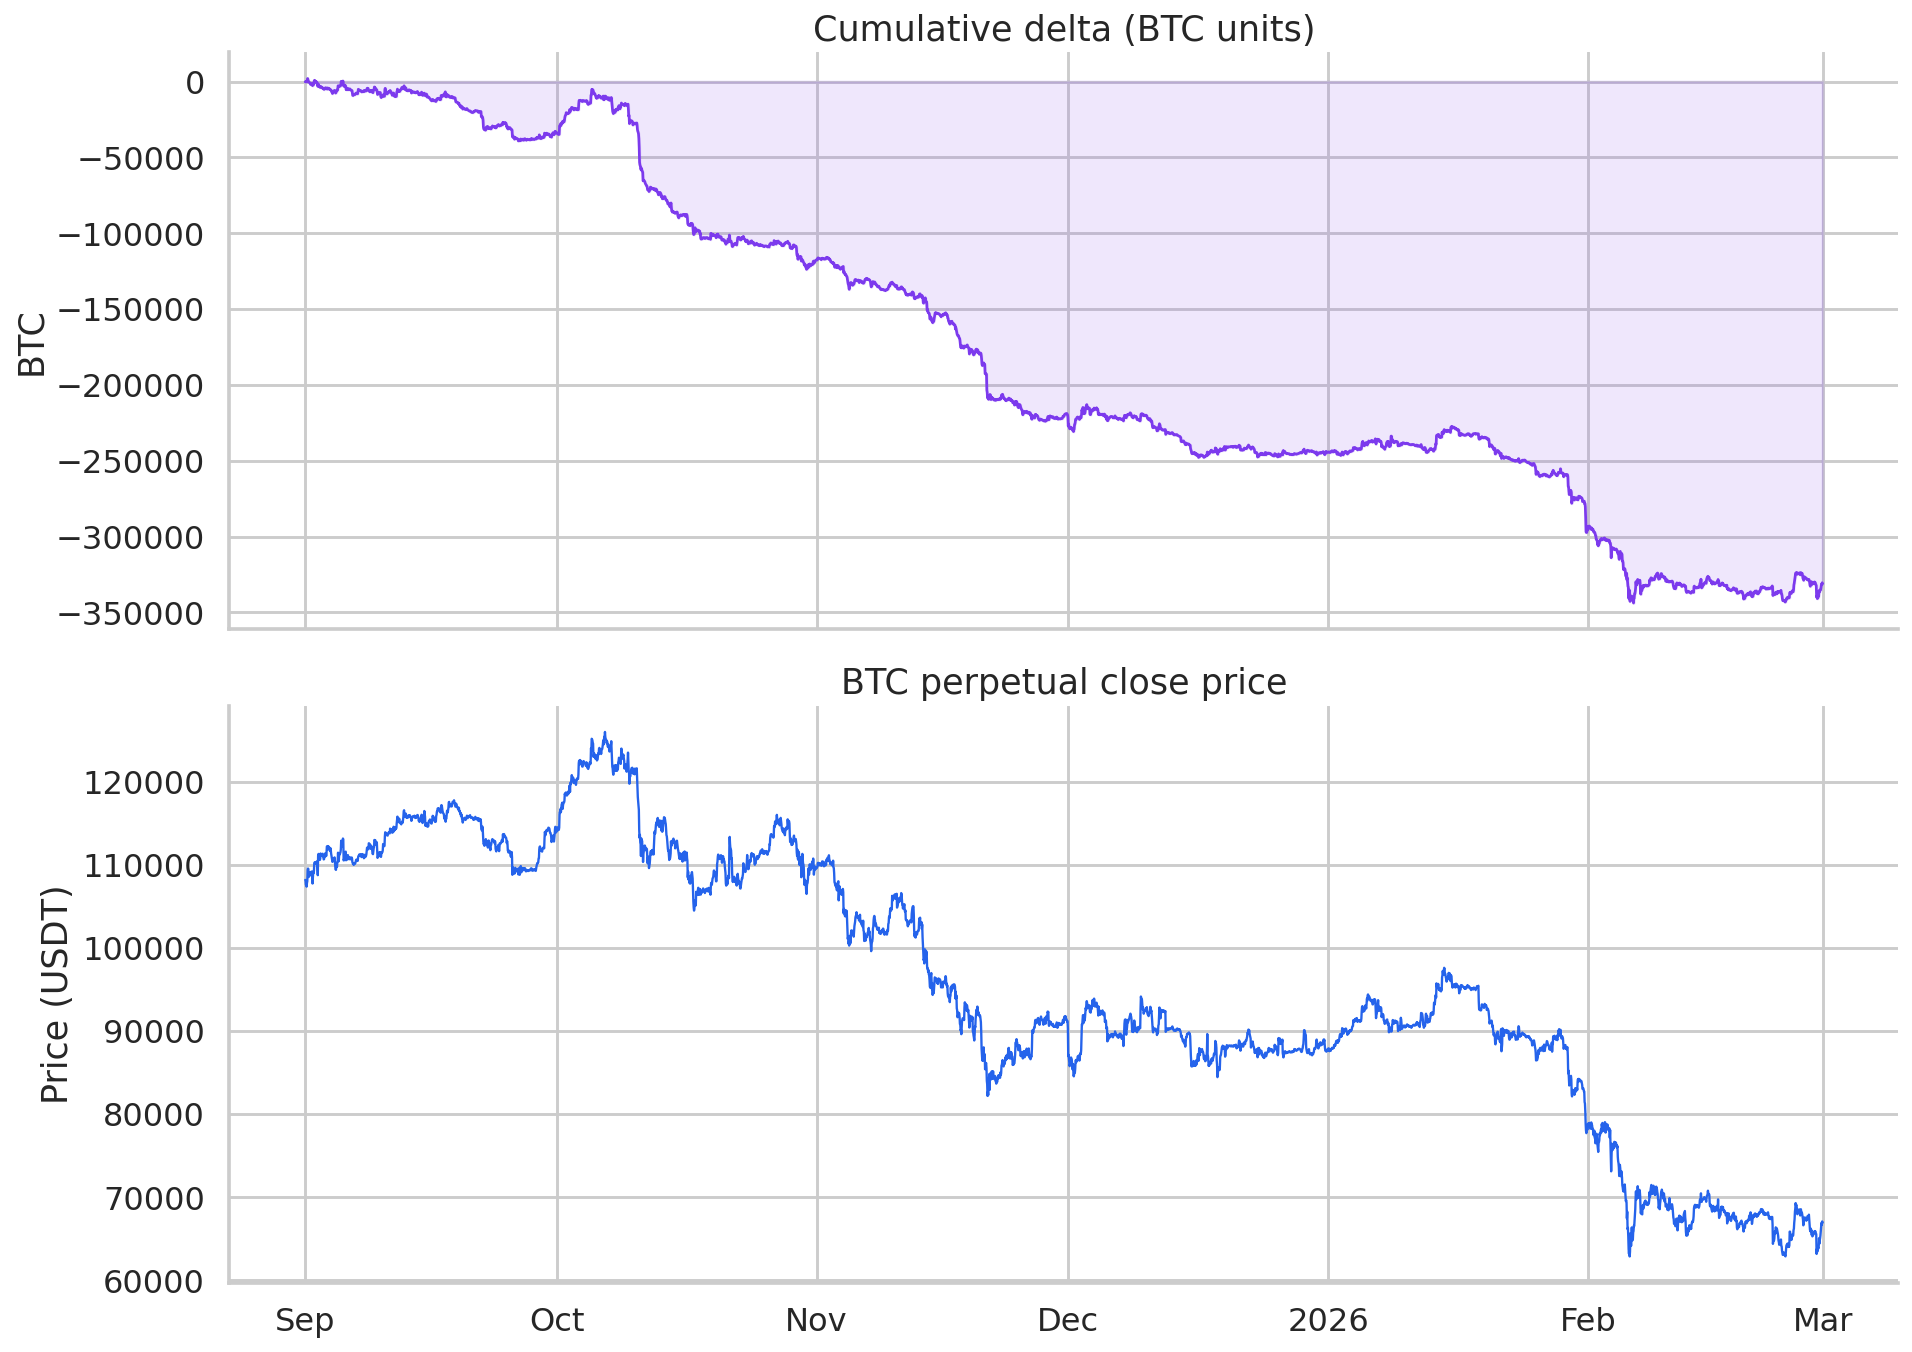

In [6]:
fig, (ax_delta, ax_price) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax_delta.plot(flow["time"], flow["cumulative_delta"], color="#7c3aed", linewidth=1.4)
ax_delta.fill_between(flow["time"], flow["cumulative_delta"], alpha=0.12, color="#7c3aed")
ax_delta.set_title("Cumulative delta (BTC units)")
ax_delta.set_ylabel("BTC")
format_time_axis(ax_delta)

ax_price.plot(flow["time"], flow["close"], color="#2563eb", linewidth=1.2)
ax_price.set_title("BTC perpetual close price")
ax_price.set_ylabel("Price (USDT)")
format_time_axis(ax_price)
plt.tight_layout()

## Chart 4 — One-day rolling buy/sell ratio

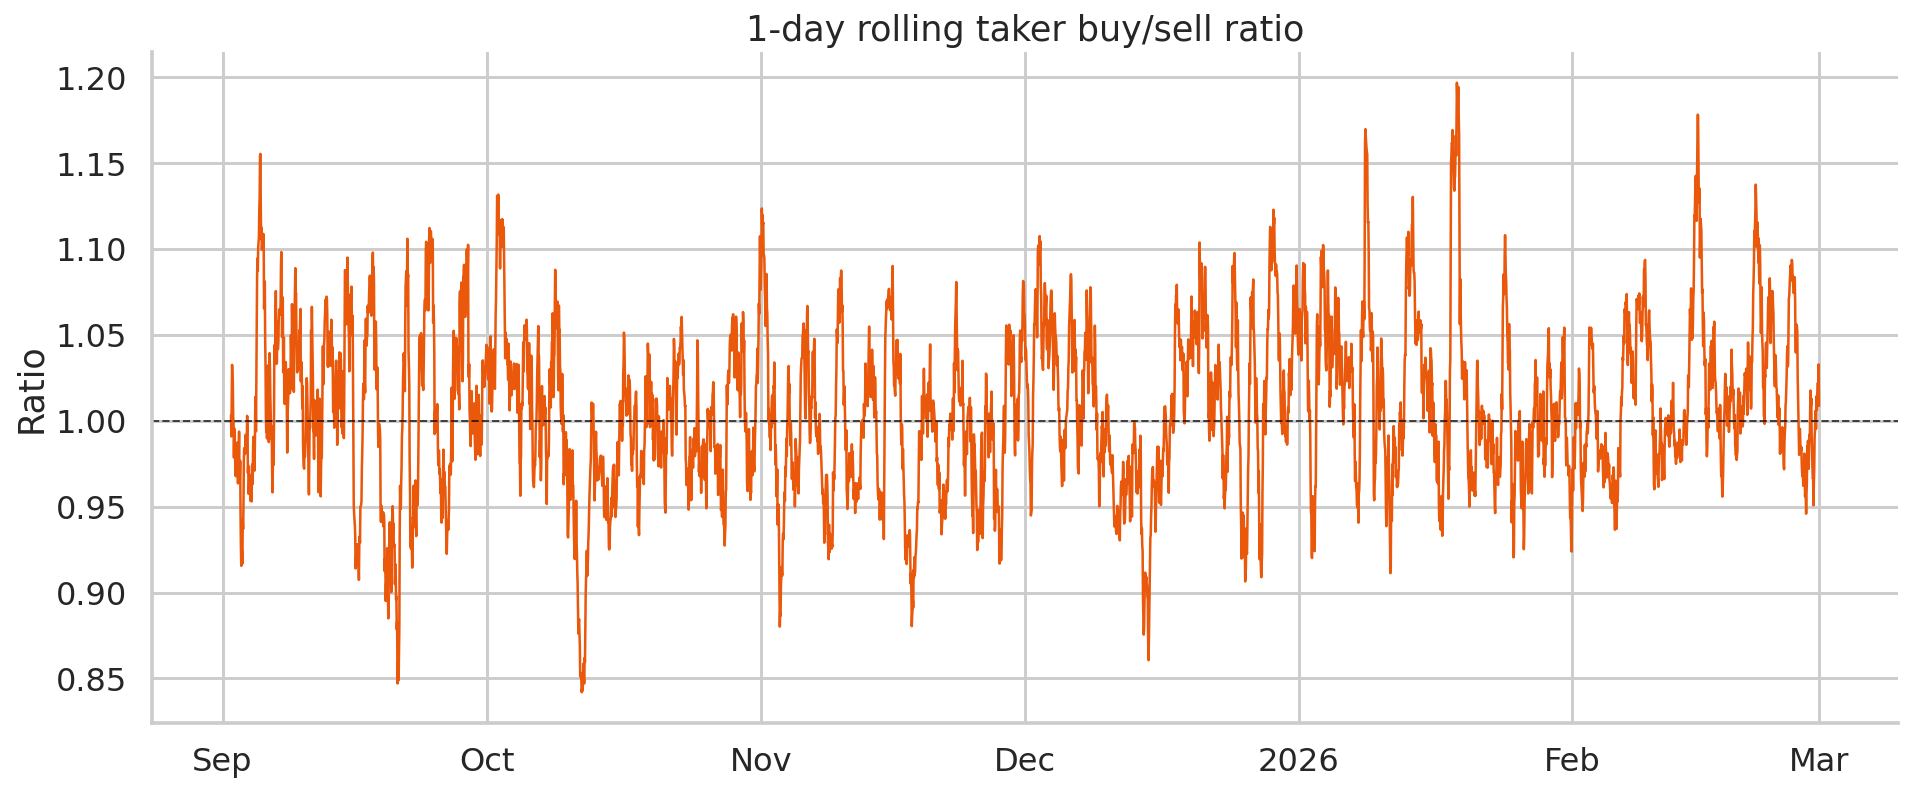

In [7]:
fig, ax = plt.subplots()
ax.plot(flow["time"], flow["rolling_buy_sell_ratio_1d"], color="#ea580c", linewidth=1.3)
ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.7)
ax.set_title("1-day rolling taker buy/sell ratio")
ax.set_ylabel("Ratio")
format_time_axis(ax)
plt.tight_layout()

## Chart 5 — Large-trade participation

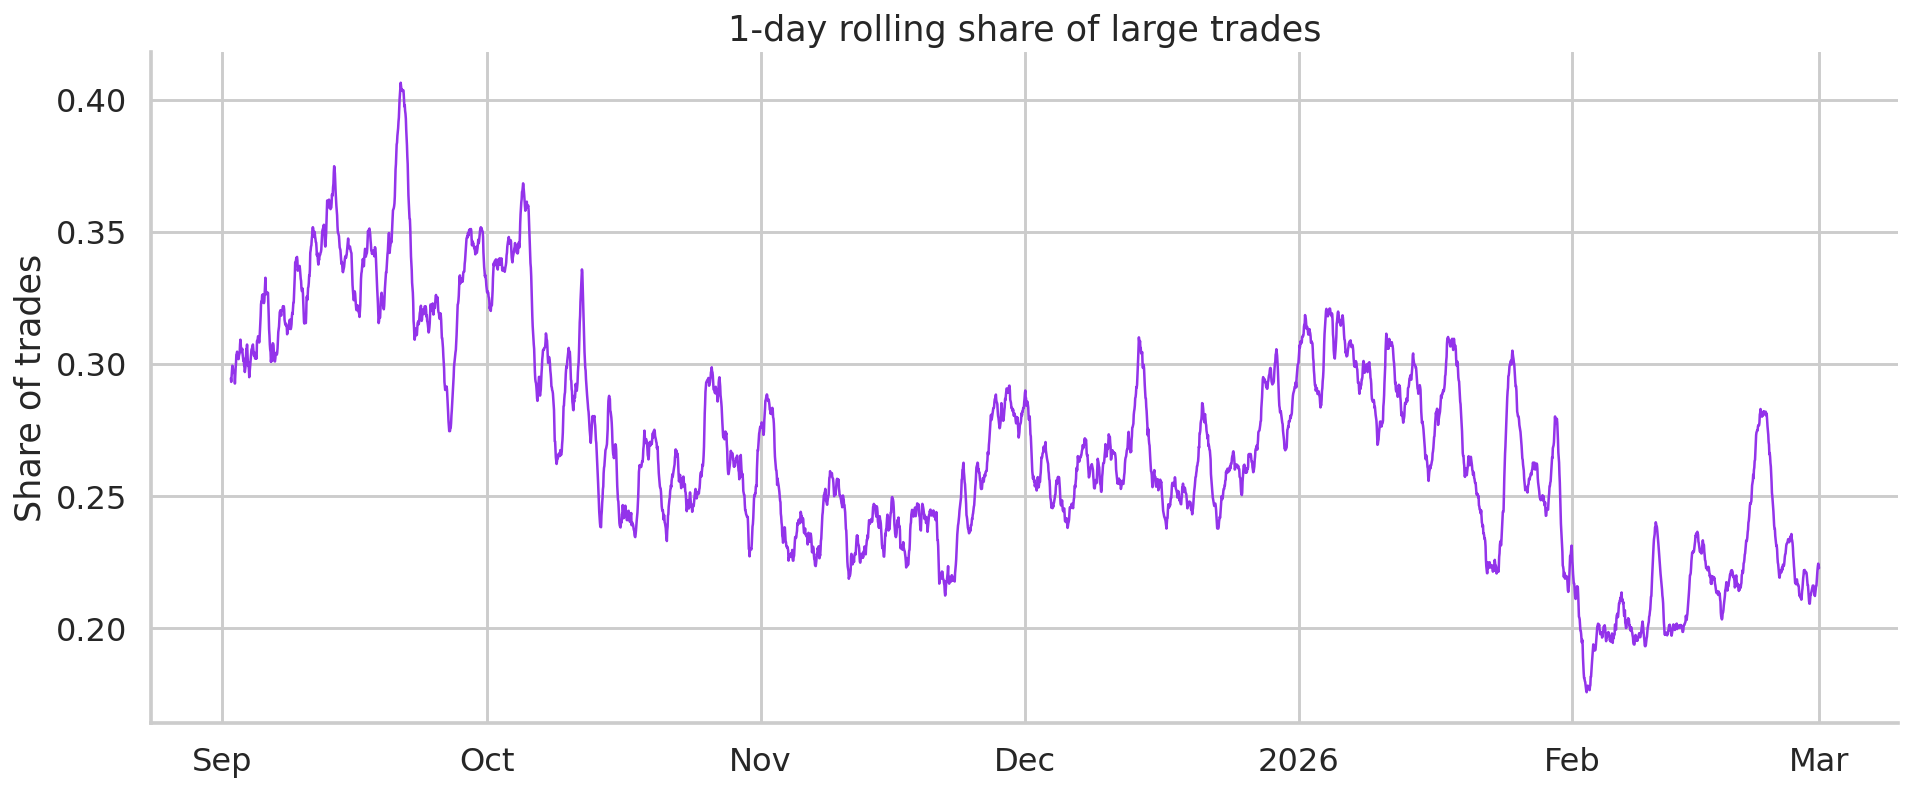

In [8]:
fig, ax = plt.subplots()
ax.plot(flow["time"], flow["large_trade_share_1d"], color="#9333ea", linewidth=1.3)
ax.set_title("1-day rolling share of large trades")
ax.set_ylabel("Share of trades")
format_time_axis(ax)
plt.tight_layout()

## Chart 6 — Absolute flow shock and BTC price

This view pairs the absolute net-delta z-score with BTC price to show whether unusually stretched flow episodes lined up with major price moves.

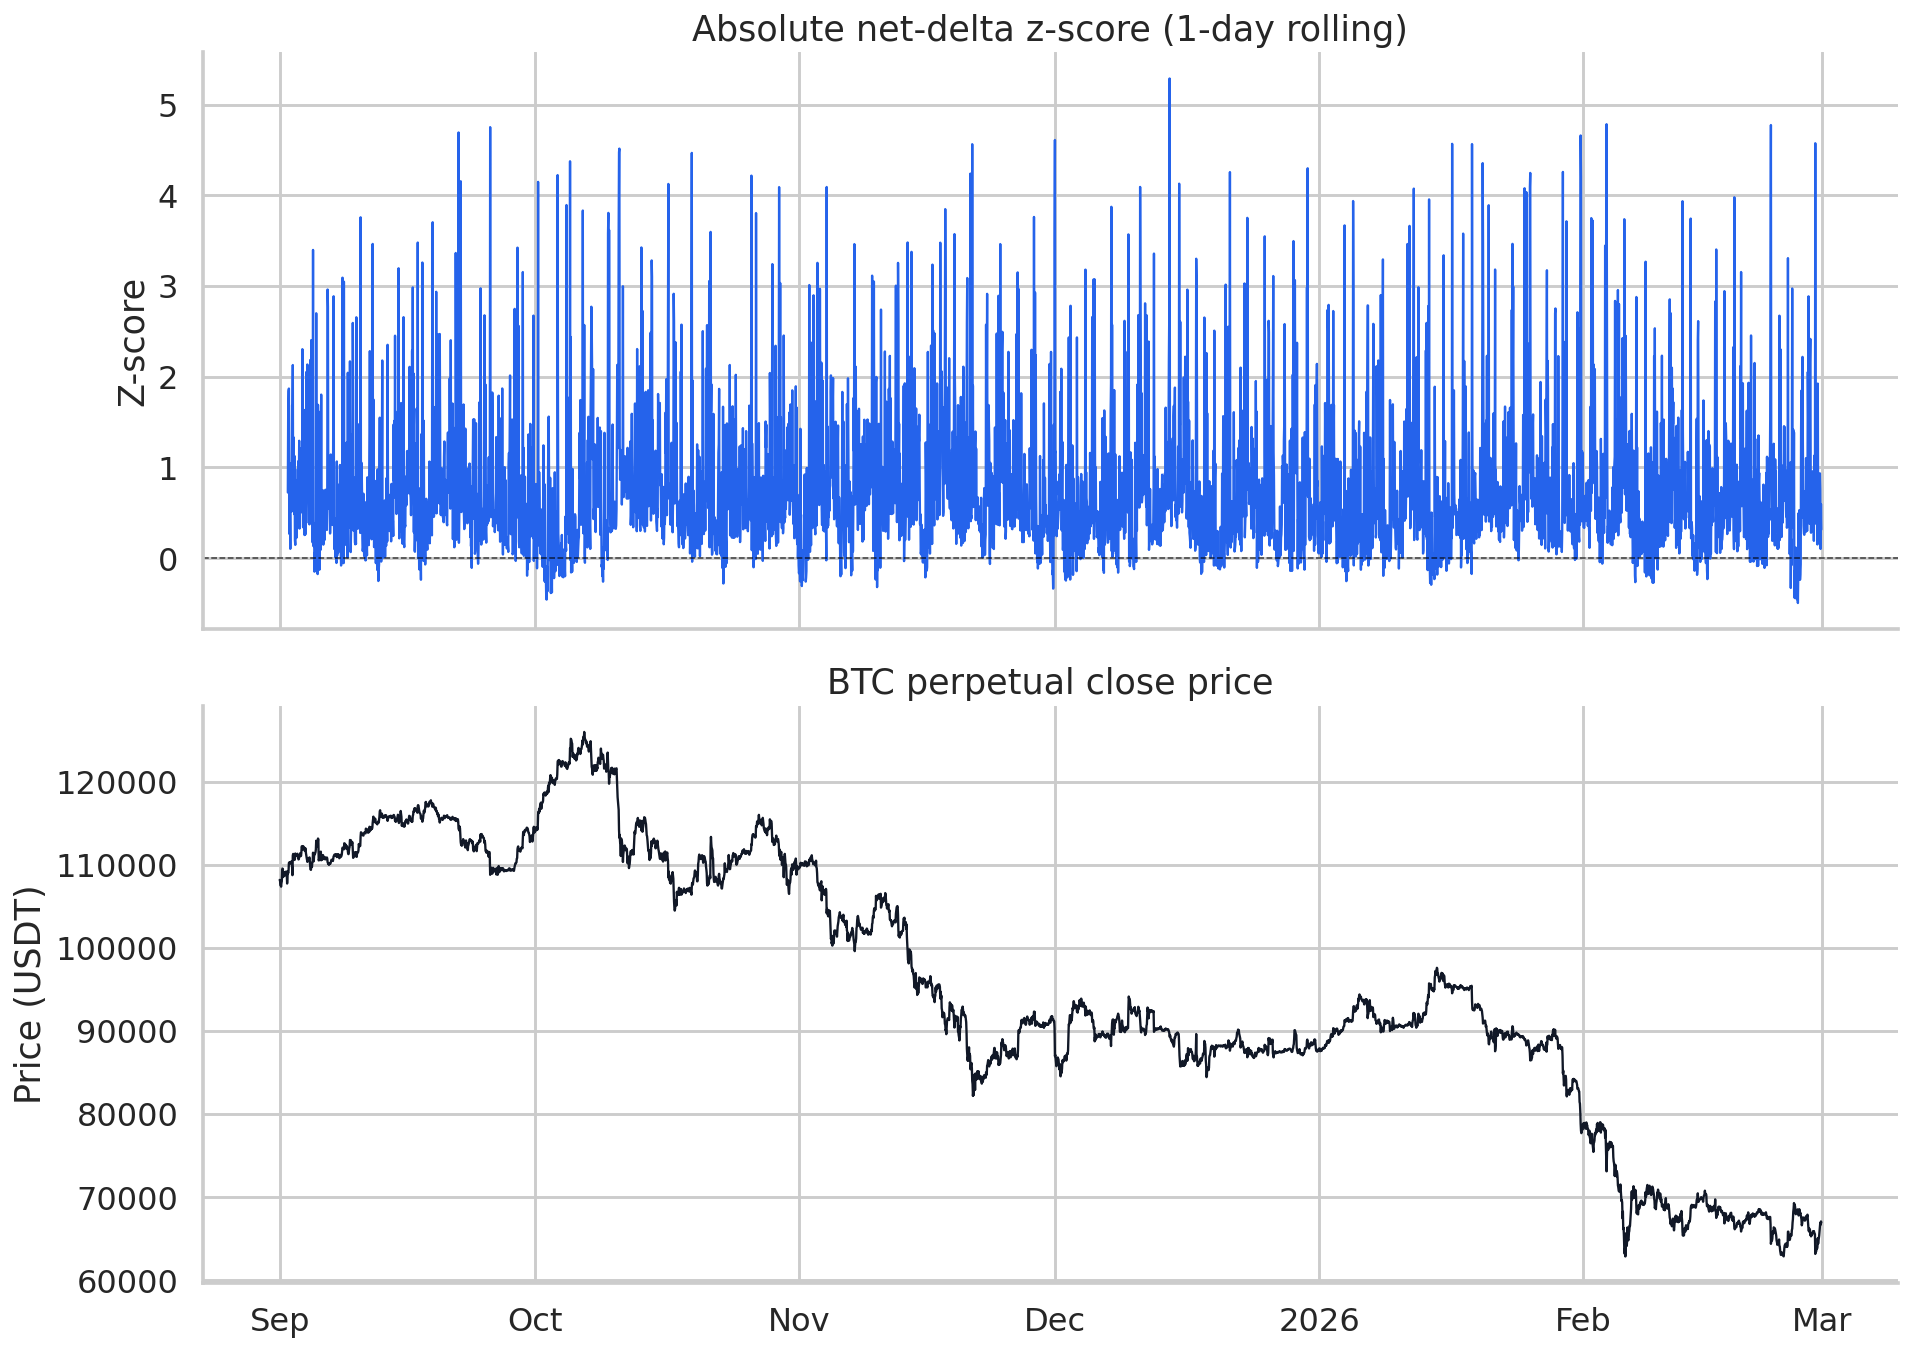

In [9]:
fig, (ax_zscore, ax_price) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
ax_zscore.plot(flow["time"], flow["abs_delta_zscore_1d"], color="#2563eb", linewidth=1.2)
ax_zscore.axhline(0, color="black", linestyle="--", linewidth=0.8, alpha=0.7)
ax_zscore.set_title("Absolute net-delta z-score (1-day rolling)")
ax_zscore.set_ylabel("Z-score")
format_time_axis(ax_zscore)

ax_price.plot(flow["time"], flow["close"], color="#111827", linewidth=1.2)
ax_price.set_title("BTC perpetual close price")
ax_price.set_ylabel("Price (USDT)")
format_time_axis(ax_price)
plt.tight_layout()

## Chart 7 — Intraday buy/sell ratio seasonality

The heatmap below highlights which weekday/hour combinations tended to have the strongest average taker buy/sell ratio.

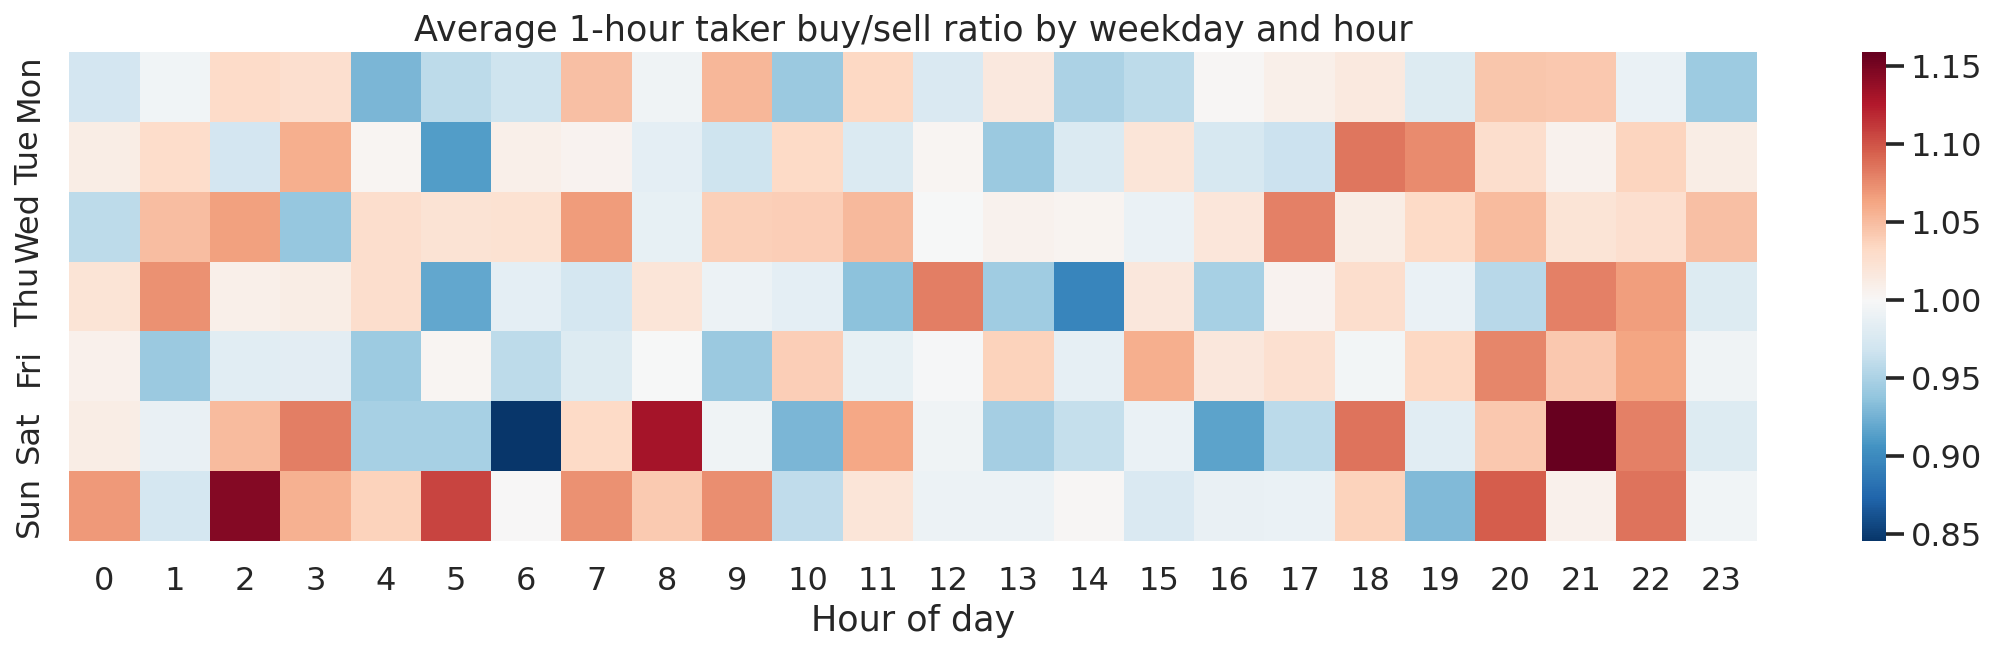

In [10]:
seasonality = flow.assign(
    weekday=flow["time"].dt.day_name().str[:3],
    hour=flow["time"].dt.hour,
).pivot_table(
    index="weekday",
    columns="hour",
    values="taker_buy_sell_ratio",
    aggfunc="mean",
)
seasonality = seasonality.reindex(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(seasonality, cmap="RdBu_r", center=1.0, ax=ax)
ax.set_title("Average 1-hour taker buy/sell ratio by weekday and hour")
ax.set_xlabel("Hour of day")
ax.set_ylabel("")
plt.tight_layout()

## Takeaways

- BTC perpetual flow is **highly bursty** even at a 1-hour horizon.
- Cumulative delta helps separate short-lived noise from persistent aggressive buying/selling pressure.
- Large-trade participation and toxicity-style features add useful **microstructure context** beyond raw buy/sell volume.
- For practical trading research, flow is usually most useful **alongside price, liquidity, and derivatives positioning** rather than by itself.

## Further reading
- Aperiodic: https://aperiodic.io/
- Makers vs takers: https://www.binance.com/en/academy/articles/what-are-makers-and-takers
- Order books: https://www.binance.com/en/academy/articles/what-is-an-order-book-and-how-does-it-work
